In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import numpy as np
import sys
import os

sys.path.append(os.path.abspath("code"))
from data_utils import download_data
import lfp_functions as lf

In [14]:
# sns.set_theme(context='notebook',style='white',font_scale=1.5,
#               rc = {'axes.spines.top':False,'axes.spines.right':False,
#                      'image.cmap':plt.cm.jet})

sns.set_theme(context='notebook', style='white', font_scale=1.5,
              rc={'axes.spines.top': False, 'axes.spines.right': False})





In [15]:
download_data('https://surfdrive.surf.nl/files/index.php/s/9nY01qMimFLez40')

## Exercise 1: explore filter parameters
---
In this exercises you will explore how different parameters affect the filtering process.
- Import the data form `data/moving_lfp.pickle` (the file is already on your machine if you run the `download_data()` cell in the main lesson)
- Take a few seconds of the data, and filter them in different frequency bands. Plot the resulting singal.
  Fix the central frequency and play with the width of the band, then try to change the central frequency of the band.
- Change the order of the filter, keeping the frequency band fixed. How does the filtered signal change? How does the computing time change? (You can try to quantify the computing time with the jupyter magic command [`%timeit`](https://docs.python.org/3/library/timeit.html) )
- Comment on what you see

In [16]:
with open('data/moving_lfp.pickle', 'rb') as handle:
    lfp_data = pickle.load(handle)

lfp = lfp_data['lfp']
sampling_rate = lfp_data['sampling_rate']
print(f'Loaded {len(lfp) / sampling_rate} seconds of LFP, sampled at {sampling_rate} Hz')


Loaded 600.133 seconds of LFP, sampled at 1000.0 Hz


In [17]:
#First step is to select the segment we want. For this:
from scipy.fft import fft, fftfreq
start_time=4*sampling_rate
stop_time= 10*sampling_rate
#we are multiplying by sampling rate because the original data is a list of indices. And then we are selecting the indices
data_segment= lfp [int(start_time):int(stop_time)]
# I am taking 6 seconds of data that will be used for all the following analysis


time_axis = np.linspace(start_time, stop_time, len(data_segment))
time_axis_seconds = np.linspace(start_time/sampling_rate, stop_time/sampling_rate, len(data_segment))




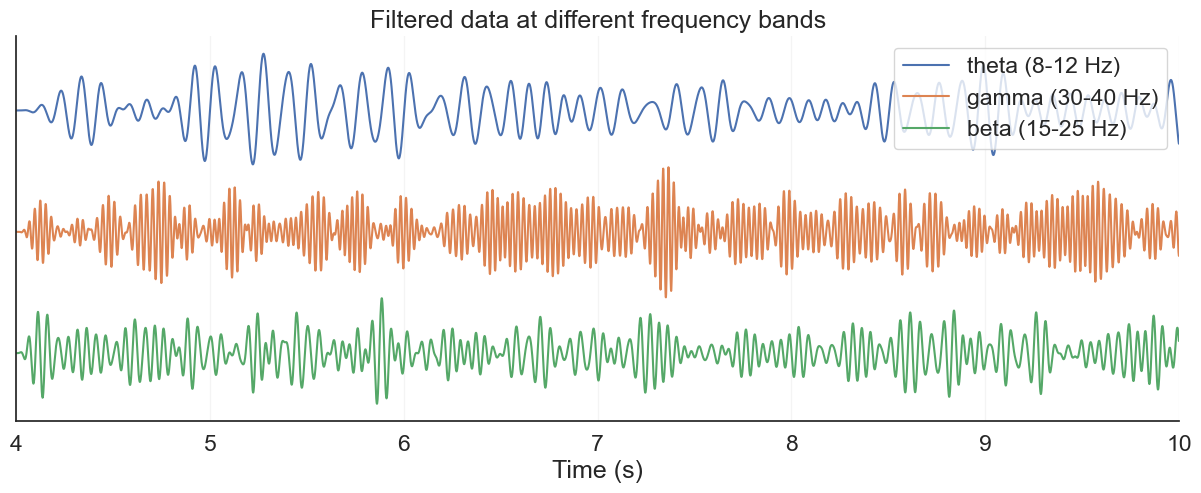

In [18]:
#Filtering the signal at different frequency bands
theta_wave = lf.bandpass_filter(data_segment, low_f=8, high_f=12, sampling_rate=sampling_rate)
gamma_wave= lf.bandpass_filter(data_segment, low_f=30, high_f=40, sampling_rate=sampling_rate)
beta_wave = lf.bandpass_filter(data_segment, low_f=15, high_f=25, sampling_rate=sampling_rate)

#Plotting
plot_offset = 200

plt.figure(figsize=(15, 5))
plt.plot(time_axis_seconds,theta_wave+ 2 * plot_offset, label='theta (8-12 Hz)')
plt.plot(time_axis_seconds,gamma_wave + plot_offset, label='gamma (30-40 Hz)')
plt.plot(time_axis_seconds, beta_wave, label='beta (15-25 Hz)')

plt.xlabel('Time (s)')
plt.yticks([])
plt.title('Filtered data at different frequency bands')

plt.xlim(time_axis_seconds[0], time_axis_seconds[-1])

plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)
plt.show()

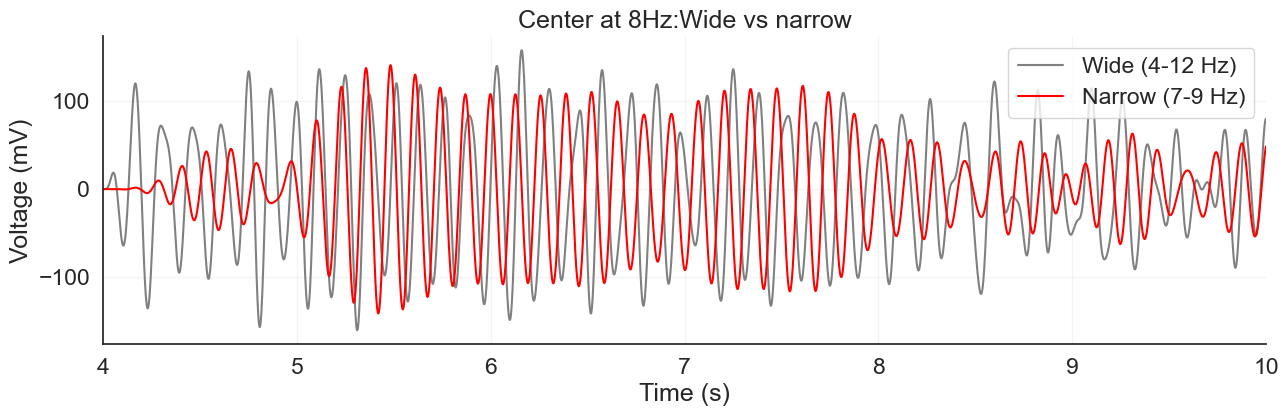

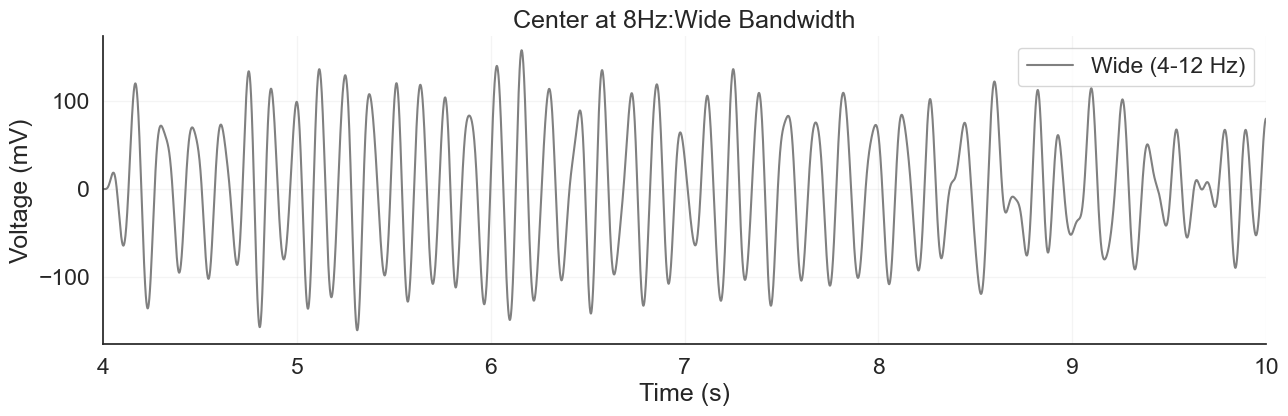

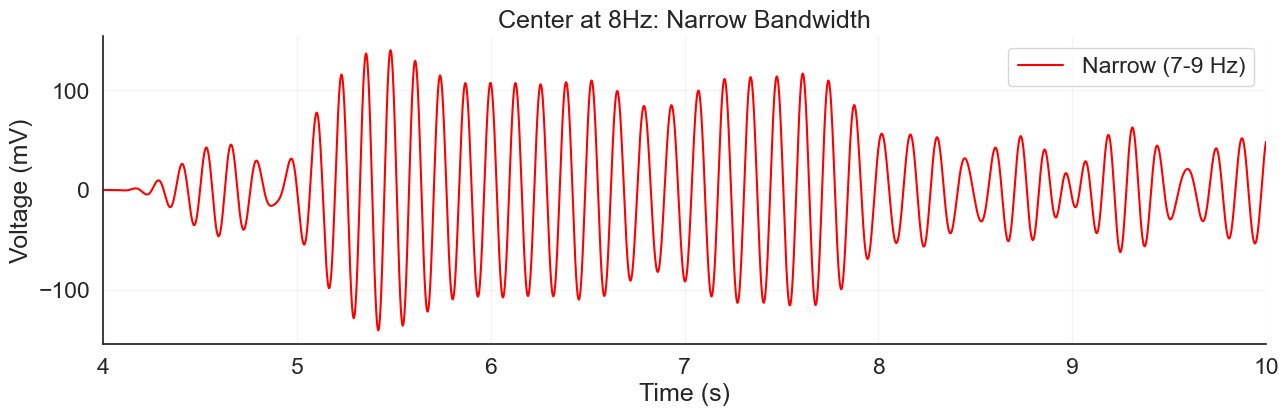

In [19]:
#Fixing the center to 8Hz and playing with the bandwidth
wide_band = lf.bandpass_filter(data_segment, low_f=4, high_f=12, sampling_rate=sampling_rate)
narrow_band= lf.bandpass_filter(data_segment, low_f=7, high_f=9, sampling_rate=sampling_rate)
#Plotting
plt.figure(figsize=(15, 4))
plt.plot(time_axis_seconds, wide_band, label='Wide (4-12 Hz)', color='gray')
plt.plot(time_axis_seconds, narrow_band, label='Narrow (7-9 Hz)', color='red')
plt.title('Center at 8Hz:Wide vs narrow')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (mV)')
plt.xlim(time_axis_seconds[0], time_axis_seconds[-1])
plt.grid(True, alpha=0.2)
plt.legend(loc='upper right')
plt.show()

plt.figure(figsize=(15, 4))
plt.plot(time_axis_seconds, wide_band, label='Wide (4-12 Hz)', color='gray')

plt.title('Center at 8Hz:Wide Bandwidth')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (mV)')
plt.xlim(time_axis_seconds[0], time_axis_seconds[-1])
plt.grid(True, alpha=0.2)
plt.legend(loc='upper right')
plt.show()

plt.figure(figsize=(15, 4))
plt.plot(time_axis_seconds, narrow_band, label='Narrow (7-9 Hz)', color='red')

plt.title('Center at 8Hz: Narrow Bandwidth')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (mV)')
plt.xlim(time_axis_seconds[0], time_axis_seconds[-1])
plt.grid(True, alpha=0.2)
plt.legend(loc='upper right')
plt.show()

*Observations for filter bandwidth*: Despite both filters are centered at 8Hz, the bandwidth determines the accuracy of capturing data. Narrow bandwidth filtering (7-9Hz) is more strict making the signal smother, while wide bandwidth filtering(4-12Hz) is more permissive capturing the full spectrum of the theta band.

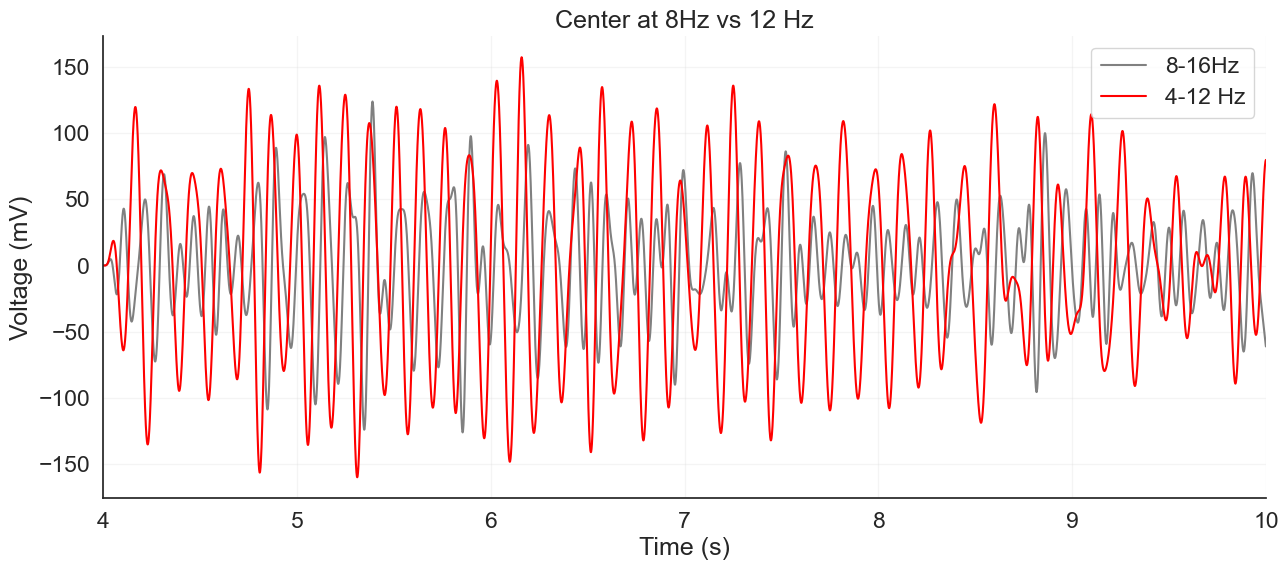

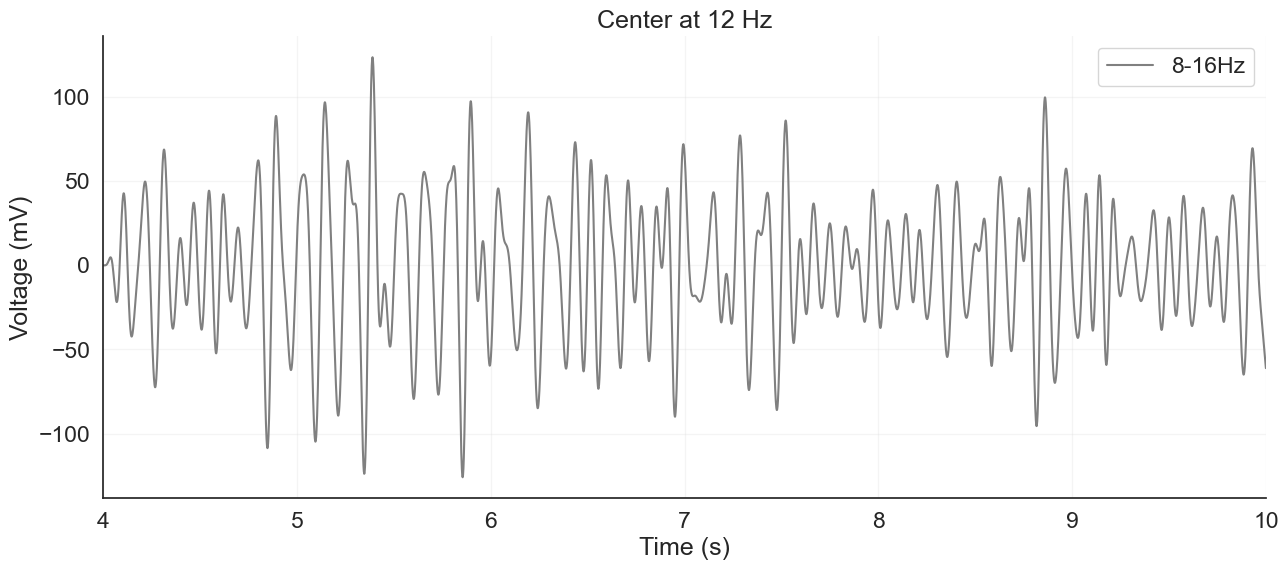

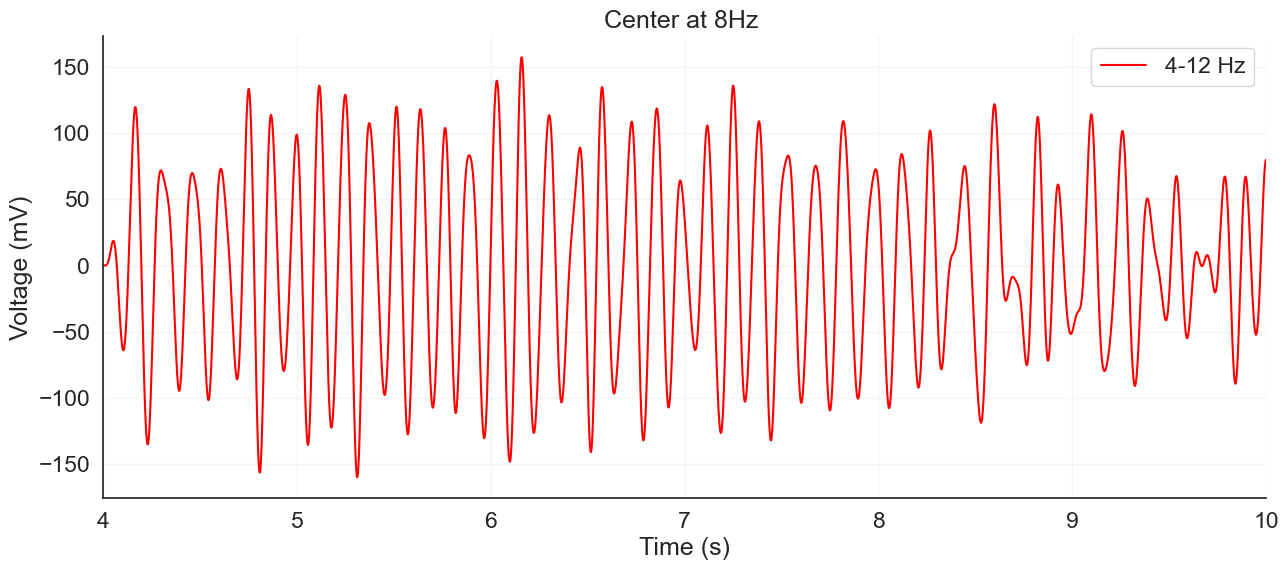

In [20]:
#Changing the center

center_12_band = lf.bandpass_filter(data_segment, low_f=8, high_f=16, sampling_rate=sampling_rate)
center_8_band= lf.bandpass_filter(data_segment, low_f=4, high_f=12, sampling_rate=sampling_rate)

plot_offset = 200

plt.figure(figsize=(15, 6))

plt.plot(time_axis_seconds, center_12_band, label='8-16Hz', color='gray')
plt.plot(time_axis_seconds, center_8_band, label='4-12 Hz', color='red')

plt.title('Center at 8Hz vs 12 Hz')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (mV)')
plt.xlim(time_axis_seconds[0], time_axis_seconds[-1])
plt.grid(True, alpha=0.2)
plt.legend( loc='upper right')
plt.show()

plt.figure(figsize=(15, 6))

plt.plot(time_axis_seconds, center_12_band, label='8-16Hz', color='gray')
plt.title('Center at 12 Hz')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (mV)')
plt.xlim(time_axis_seconds[0], time_axis_seconds[-1])
plt.grid(True, alpha=0.2)
plt.legend( loc='upper right')
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(time_axis_seconds, center_8_band, label='4-12 Hz', color='red')
plt.title('Center at 8Hz ')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (mV)')
plt.xlim(time_axis_seconds[0], time_axis_seconds[-1])
plt.grid(True, alpha=0.2)
plt.legend( loc='upper right')
plt.show()

*Observations for central frequency*:
Changing the central frequency without changing the bandwidth has an effect on the frequencies that we are analyzing. By moving the center from 8Hz to 12 Hz we transition from analyzing Theta rhythm to capturing faster oscillations (alpha range)

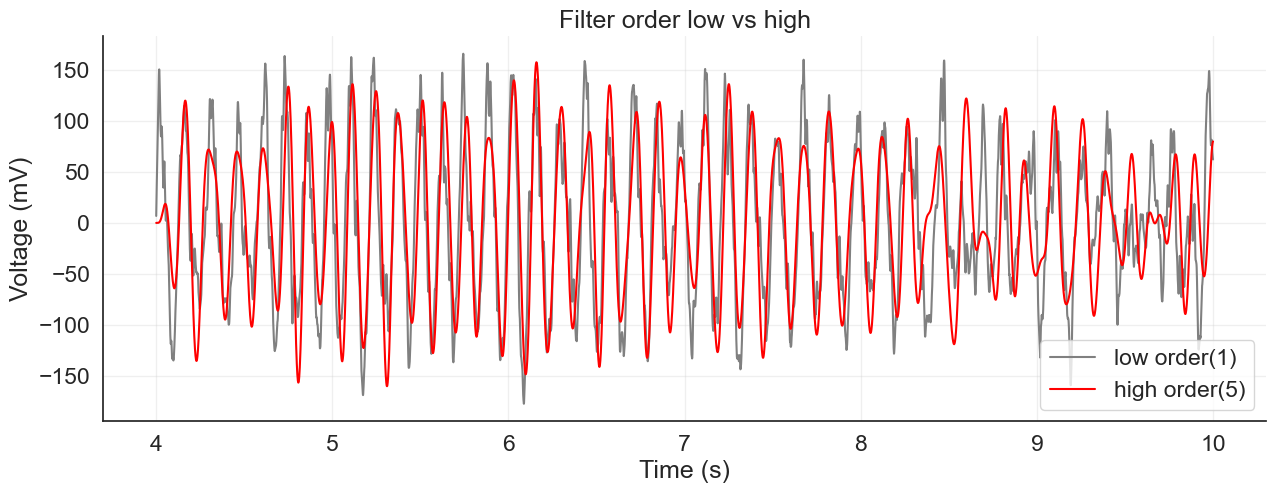

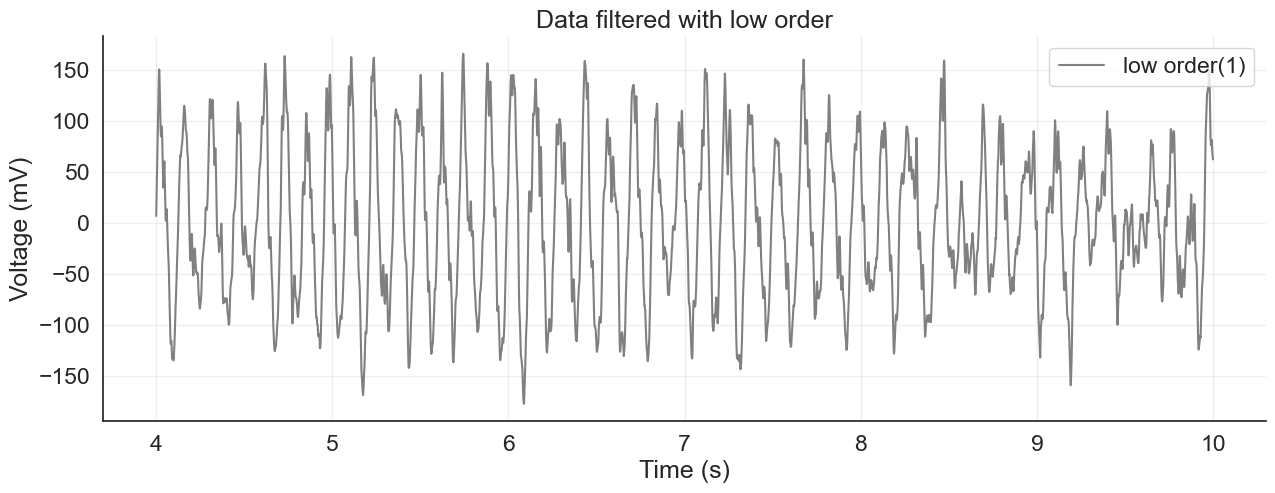

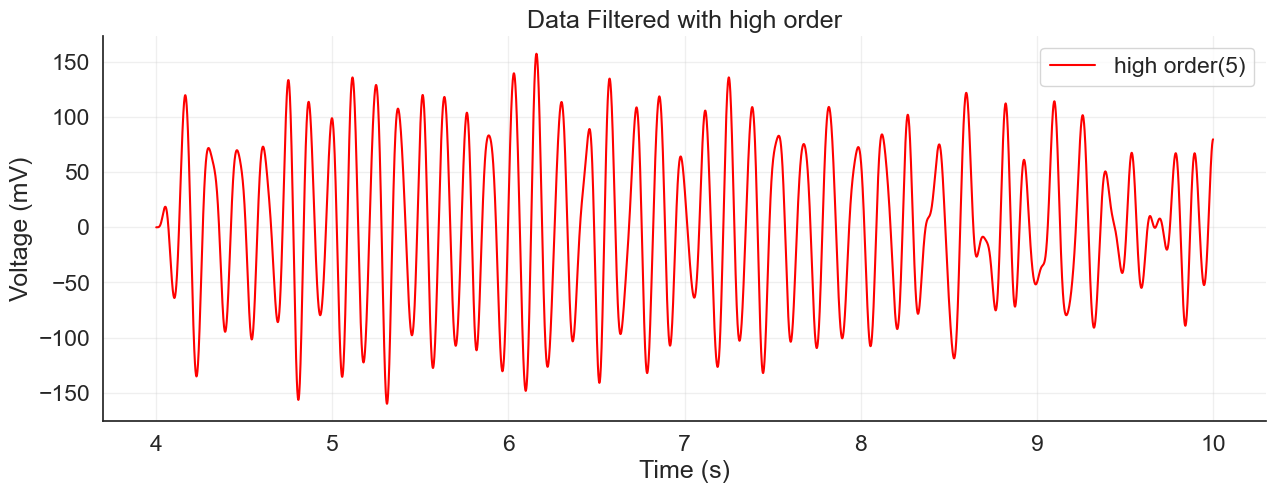

In [21]:
#Changing the order of the filter
from scipy.signal import butter
from scipy.signal import sosfilt

order_low = 1
order_high=5
low_f = 4
high_f = 12


filter_order_low = butter(order_low, [low_f, high_f],
                btype='band',
                output='sos',
                fs=sampling_rate)
filter_order_high= butter(order_high, [low_f, high_f],
                btype='band',
                output='sos',
                fs=sampling_rate)

#apply filter to lfp
theta_low_order = sosfilt(filter_order_low, data_segment)
theta_high_order= sosfilt(filter_order_high,data_segment)

plt.figure(figsize=(15, 5))
plt.plot(time_axis_seconds, theta_low_order, label='low order(1)', color='gray')
plt.plot(time_axis_seconds, theta_high_order, label='high order(5)', color='red')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (mV)')
plt.title('Filter order low vs high')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(15, 5))
plt.plot(time_axis_seconds, theta_low_order, label='low order(1)', color='gray')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (mV)')
plt.title('Data filtered with low order')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(15, 5))
plt.plot(time_axis_seconds, theta_high_order, label='high order(5)', color='red')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (mV)')
plt.title('Data Filtered with high order')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()


In [22]:
# Compare computing times between Order 1 and Order 5
from scipy.signal import butter, sosfiltfilt

low_f, high_f = 4, 12
fs = sampling_rate

def test_order(o):
    sos = butter(o, [low_f, high_f], btype='band', output='sos', fs=fs)
    return sosfiltfilt(sos, data_segment)

print("Computing time for Order 1:")
%timeit test_order(1)

print("\nComputing time for Order 5:")
%timeit test_order(5)

#NOTE: I first tried with lf.bandpass_filter but it uses a fixed order ( i could not change the order). To solve this I used SciPy's butter and sosfiltfilt."

Computing time for Order 1:
659 μs ± 28.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)

Computing time for Order 5:
1.53 ms ± 123 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


*Observations for Order filter*:

The order of the filter seems to affect the smoothness and clarity of the signal. Applying a low order filter (1), generates a noisy output. In contrast, applying a high order filter produces a smoother signal.

However, precision has a computational trade-off observable in the computational time. Computing time for order 5 is the double that of order 1. This suggests that higher order filters requires more complex mathematical operations

## Exercise 2: wavelet transform with real wavelets
---
In this exercises you will explore the difference between real and complex wavelets in the continous wavelet transform.
- Import the data form `data/moving_lfp.pickle`
- Select a period of a few seconds of the signal and compute the spectrogram.
  Try the wavelet transform with wavelet `mexh` (mexican hat),`gaus` (gaussian) and `morl` (morlet). These are all real wavelets.
- What differences do you see with respect to the spectrum computed with the complex Morlet tranform ? Comment on why do you think this might be the case.

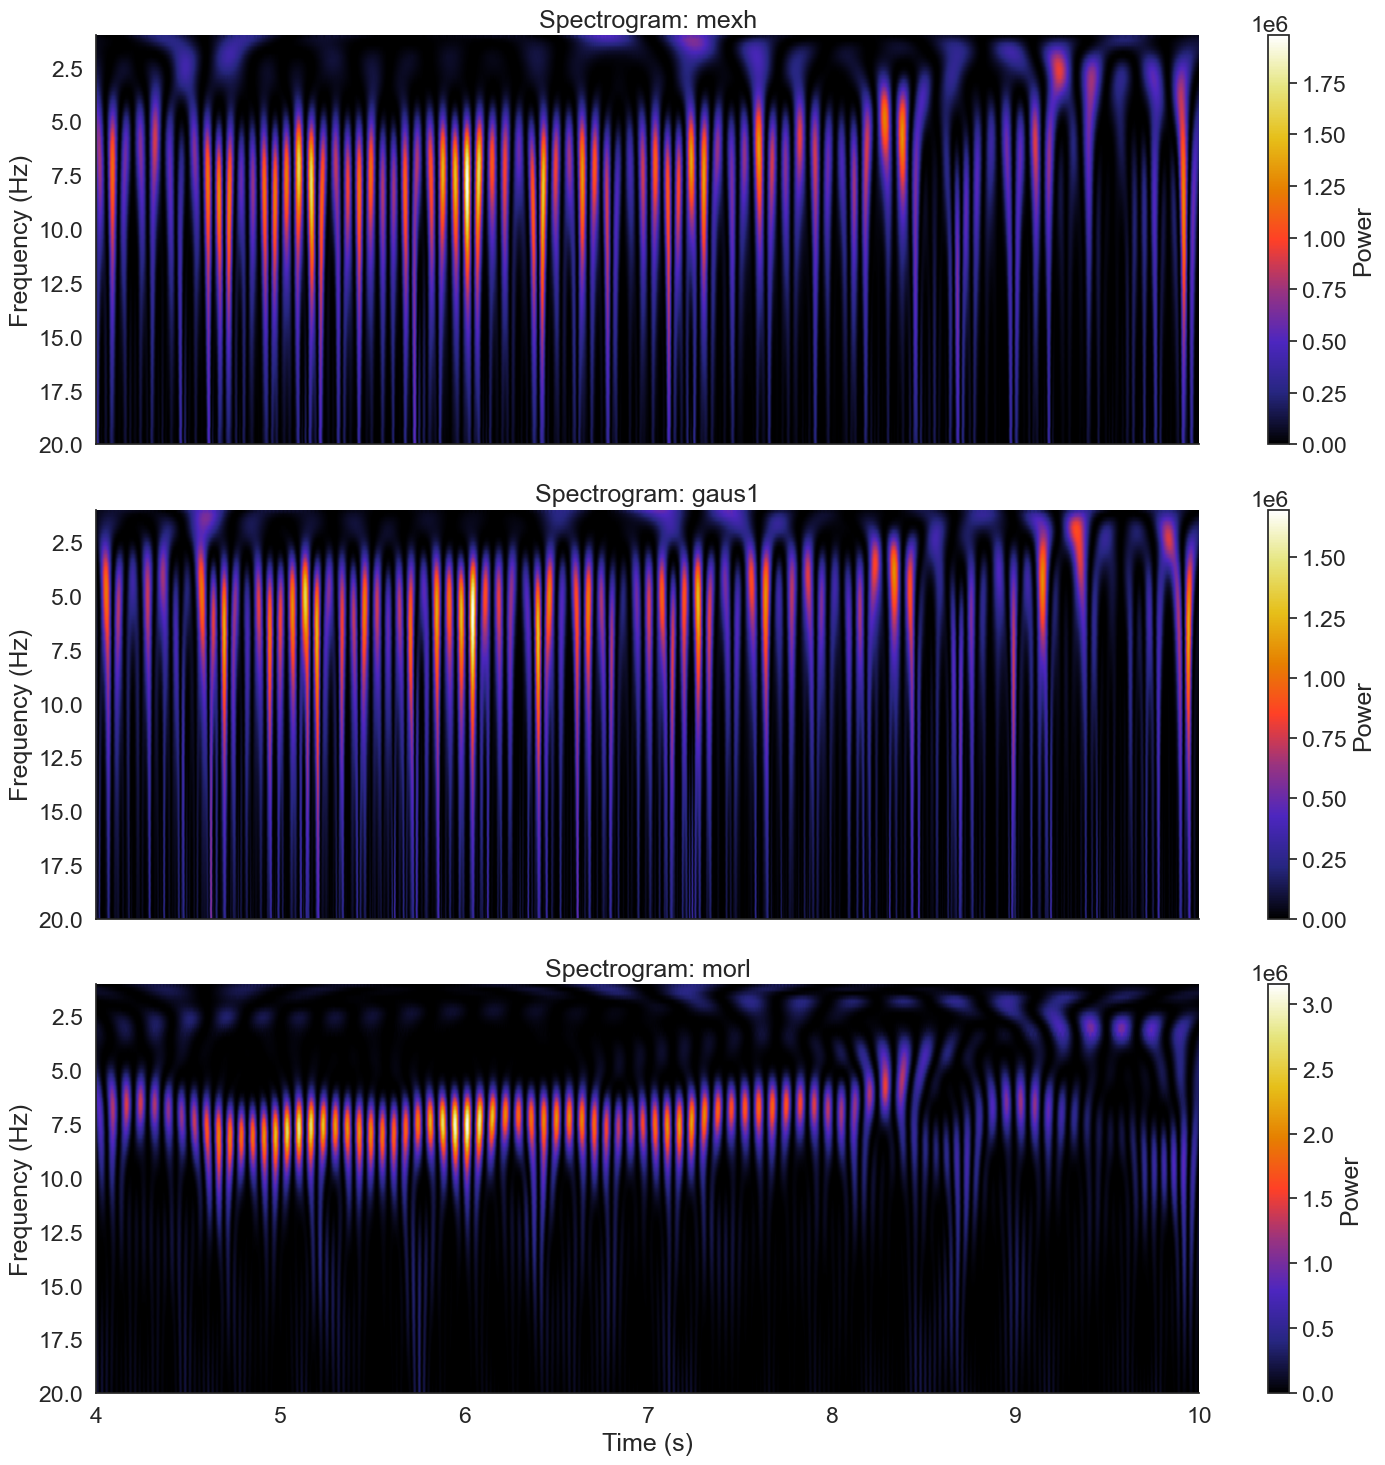

In [23]:
from pywt import scale2frequency, cwt
import numpy as np
import matplotlib.pyplot as plt


sig = data_segment - np.mean(data_segment)
wavelets = ['mexh', 'gaus1', 'morl']
frequencies = np.linspace(1, 20, 100) / sampling_rate


fig, axes = plt.subplots(3, 1, figsize=(15, 15), sharex=True)

for i, wv in enumerate(wavelets):

    scales = scale2frequency(wv, frequencies)
    cwtmatr, _ = cwt(sig, wavelet=wv, scales=scales, sampling_period=1.0/sampling_rate)

    power = np.abs(cwtmatr)**2

    im = axes[i].imshow(power,
                        extent=[time_axis_seconds[0], time_axis_seconds[-1], 20, 1],
                        aspect='auto', cmap='CMRmap')

    axes[i].set_title(f'Spectrogram: {wv}')
    axes[i].set_ylabel('Frequency (Hz)')
    fig.colorbar(im, ax=axes[i], label='Power')

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

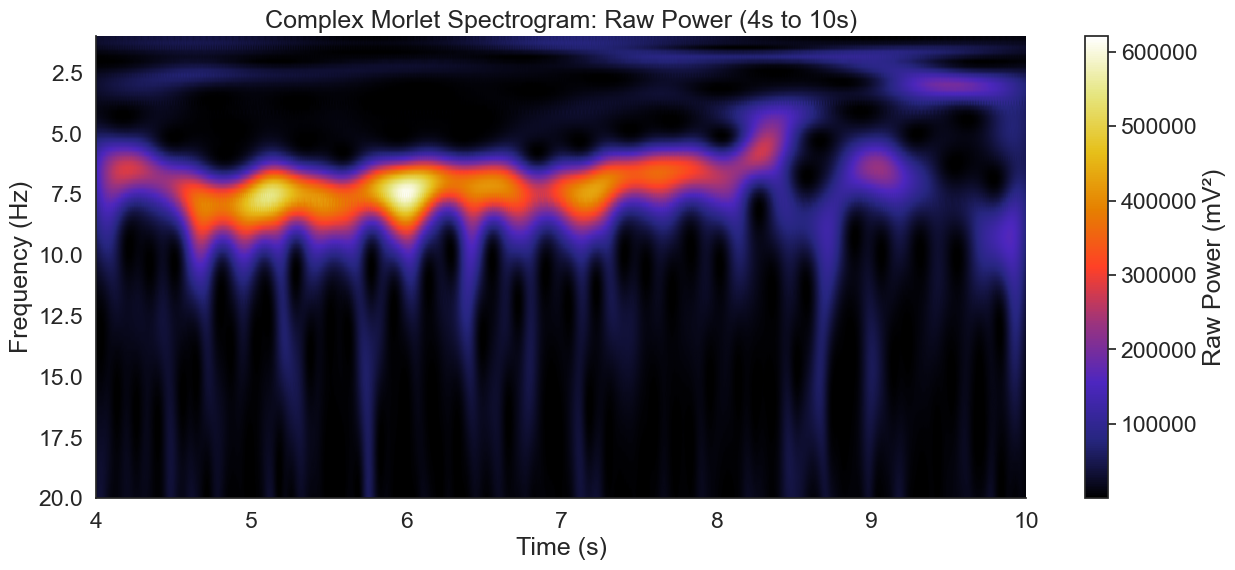

In [24]:
from pywt import scale2frequency, cwt
import numpy as np
import matplotlib.pyplot as plt


sig = data_segment - np.mean(data_segment)



frequencies = np.linspace(1, 20, 100) / sampling_rate
wavelet = 'cmor1.5-1.0'


scales = scale2frequency(wavelet, frequencies)


cwtmatr, _ = cwt(sig, wavelet=wavelet, scales=scales,
                 sampling_period=1.0/sampling_rate)


plt.figure(figsize=(15, 6))


raw_power = np.abs(cwtmatr)**2

plt.imshow(raw_power,
           extent=[time_axis_seconds[0], time_axis_seconds[-1], 20, 1],
           aspect='auto',
           cmap='CMRmap')

plt.title(f'Complex Morlet Spectrogram: Raw Power (4s to 10s)')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.colorbar(label='Raw Power (mV²)')
plt.show()

*Differences between real and complex wavelets*: The main difference is the visual appearance of the power bands. In the real wavelets, the power bands are patches appearing with a "rib" form. In contrast, in the complex morlet wavelet the spectogram shows a horizontal smooth beam.
This may occur because complex wavelets can extract the amplitude envelope.

In summary, real wavelets, which only account for one component(real part), detect the signal when the wavelet is in phase with the neural signal. Alternatively, complex wavelets are based on both real and imaginary components and can extract the overall strength of the rhythm